# Model Validation

## Objective
Validate the PD scorecard model using industry-standard metrics required for Basel II/III model approval.

## Validation metrics:
- **KS Statistic** — maximum separation between defaulter and non-defaulter score distributions
- **Gini Coefficient** — overall rank-ordering ability (= 2×AUC − 1)
- **AUC-ROC** — probability of correctly ranking a random defaulter below a random non-defaulter  
- **PSI** — population stability index, measures whether score distribution is stable between train and test sets

## Industry benchmarks:
| Metric | Poor | Acceptable | Good | Very Good |
|---|---|---|---|---|
| KS | <20 | 20-40 | 40-60 | >60 |
| Gini | <30% | 30-50% | 50-70% | >70% |
| AUC | <0.65 | 0.65-0.75 | 0.75-0.85 | >0.85 |
| PSI | >0.25 | 0.10-0.25 | <0.10 | <0.05 |

In [1]:
# ============================================================
# Setup
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

# Load scores
train = pd.read_csv('../data/train_scores.csv', index_col=0)
test  = pd.read_csv('../data/test_scores.csv',  index_col=0)

print("Data loaded successfully")
print(f"Train: {train.shape} | Test: {test.shape}")
print(f"\nTrain default rate: {train['target'].mean()*100:.2f}%")
print(f"Test default rate:  {test['target'].mean()*100:.2f}%")
print(f"\nTrain score range: {train['score'].min():.1f} to {train['score'].max():.1f}")
print(f"Test score range:  {test['score'].min():.1f} to {test['score'].max():.1f}")

Data loaded successfully
Train: (104999, 3) | Test: (45000, 3)

Train default rate: 6.68%
Test default rate:  6.68%

Train score range: 377.9 to 559.9
Test score range:  377.9 to 559.9


=== KS Statistic ===
Train KS: 49.56% at score 487.9
Test KS:  49.24%  at score 491.3

Train KS interpretation: Good
Test KS interpretation:  Good


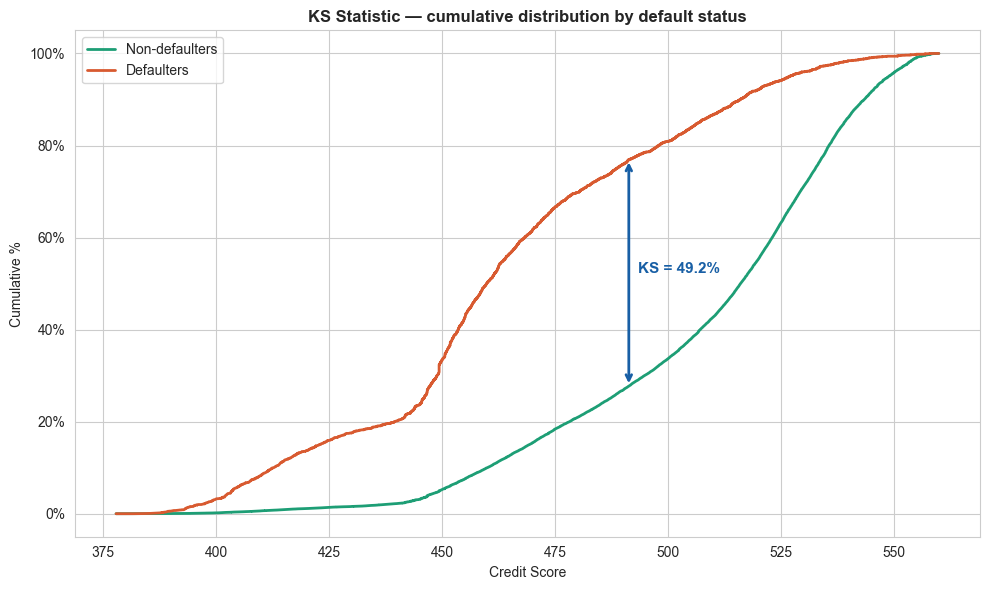

Chart saved


In [2]:
# ============================================================
# KS Statistic
# ============================================================

def calculate_ks(scores, targets):
    """
    Calculate KS statistic.
    KS = max(cumulative % of non-defaulters - cumulative % of defaulters)
    across all score thresholds.
    """
    df = pd.DataFrame({'score': scores, 'target': targets})
    df = df.sort_values('score', ascending=True).reset_index(drop=True)
    
    total_events    = df['target'].sum()
    total_nonevents = (df['target'] == 0).sum()
    
    df['cum_events']    = df['target'].cumsum() / total_events
    df['cum_nonevents'] = (1 - df['target']).cumsum() / total_nonevents
    df['ks']            = abs(df['cum_nonevents'] - df['cum_events'])
    
    ks_stat  = df['ks'].max()
    ks_score = df.loc[df['ks'].idxmax(), 'score']
    
    return ks_stat, ks_score, df

# Calculate KS for train and test
ks_train, ks_score_train, ks_df_train = calculate_ks(
    train['score'], train['target'])
ks_test,  ks_score_test,  ks_df_test  = calculate_ks(
    test['score'],  test['target'])

print(f"=== KS Statistic ===")
print(f"Train KS: {ks_train*100:.2f}% at score {ks_score_train:.1f}")
print(f"Test KS:  {ks_test*100:.2f}%  at score {ks_score_test:.1f}")

# Interpret
def interpret_ks(ks):
    ks_pct = ks * 100
    if ks_pct < 20:   return "Poor"
    elif ks_pct < 40: return "Acceptable"
    elif ks_pct < 60: return "Good"
    else:             return "Very Good"

print(f"\nTrain KS interpretation: {interpret_ks(ks_train)}")
print(f"Test KS interpretation:  {interpret_ks(ks_test)}")

# Plot KS
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(ks_df_test['score'], ks_df_test['cum_nonevents'],
        color='#1D9E75', linewidth=2, label='Non-defaulters')
ax.plot(ks_df_test['score'], ks_df_test['cum_events'],
        color='#D85A30', linewidth=2, label='Defaulters')

# KS arrow
ax.annotate('', 
    xy=(ks_score_test, ks_df_test.loc[ks_df_test['ks'].idxmax(), 'cum_events']),
    xytext=(ks_score_test, ks_df_test.loc[ks_df_test['ks'].idxmax(), 'cum_nonevents']),
    arrowprops=dict(arrowstyle='<->', color='#185FA5', lw=2))

ax.text(ks_score_test + 2, 
        (ks_df_test.loc[ks_df_test['ks'].idxmax(), 'cum_events'] + 
         ks_df_test.loc[ks_df_test['ks'].idxmax(), 'cum_nonevents']) / 2,
        f'KS = {ks_test*100:.1f}%', color='#185FA5', fontsize=11, fontweight='bold')

ax.set_xlabel('Credit Score')
ax.set_ylabel('Cumulative %')
ax.set_title('KS Statistic — cumulative distribution by default status',
             fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig('../reports/08_ks_statistic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

=== AUC-ROC & Gini ===
Train — AUC: 0.8135 | Gini: 62.70%
Test  — AUC: 0.8159  | Gini: 63.19%

Train Gini interpretation: Good
Test Gini interpretation:  Good


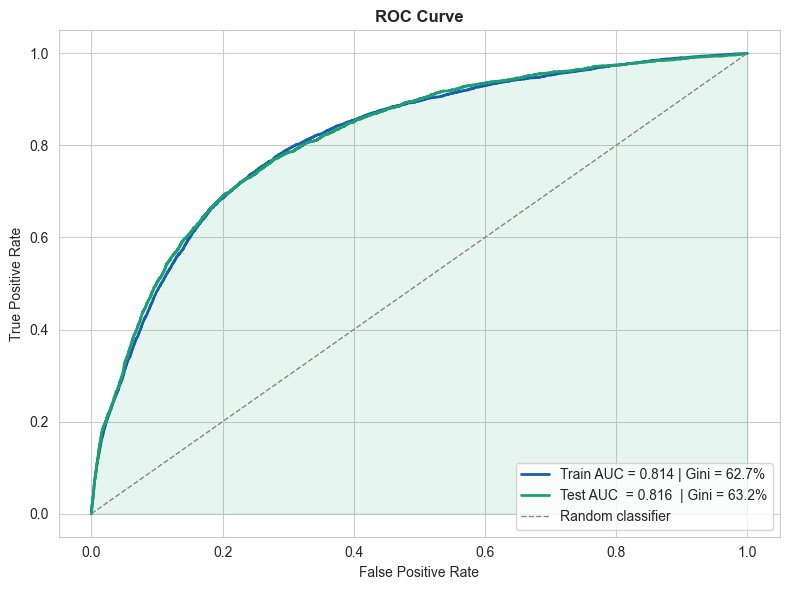

Chart saved


In [3]:
# ============================================================
# Gini & AUC-ROC
# ============================================================

# AUC — note: lower score = higher risk, so we flip the score
auc_train = roc_auc_score(train['target'], -train['score'])
auc_test  = roc_auc_score(test['target'],  -test['score'])

gini_train = 2 * auc_train - 1
gini_test  = 2 * auc_test  - 1

print(f"=== AUC-ROC & Gini ===")
print(f"Train — AUC: {auc_train:.4f} | Gini: {gini_train*100:.2f}%")
print(f"Test  — AUC: {auc_test:.4f}  | Gini: {gini_test*100:.2f}%")

def interpret_gini(gini):
    g = gini * 100
    if g < 30:   return "Poor"
    elif g < 50: return "Acceptable"
    elif g < 70: return "Good"
    else:        return "Very Good"

print(f"\nTrain Gini interpretation: {interpret_gini(gini_train)}")
print(f"Test Gini interpretation:  {interpret_gini(gini_test)}")

# ROC Curve plot
fpr_train, tpr_train, _ = roc_curve(train['target'], -train['score'])
fpr_test,  tpr_test,  _ = roc_curve(test['target'],  -test['score'])

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_train, tpr_train, color='#185FA5', linewidth=2,
        label=f'Train AUC = {auc_train:.3f} | Gini = {gini_train*100:.1f}%')
ax.plot(fpr_test,  tpr_test,  color='#1D9E75', linewidth=2,
        label=f'Test AUC  = {auc_test:.3f}  | Gini = {gini_test*100:.1f}%')
ax.plot([0,1], [0,1], color='#888780', linestyle='--', 
        linewidth=1, label='Random classifier')
ax.fill_between(fpr_test, tpr_test, alpha=0.1, color='#1D9E75')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/09_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

=== Population Stability Index ===
PSI: 0.0001
Interpretation: Stable — no action needed


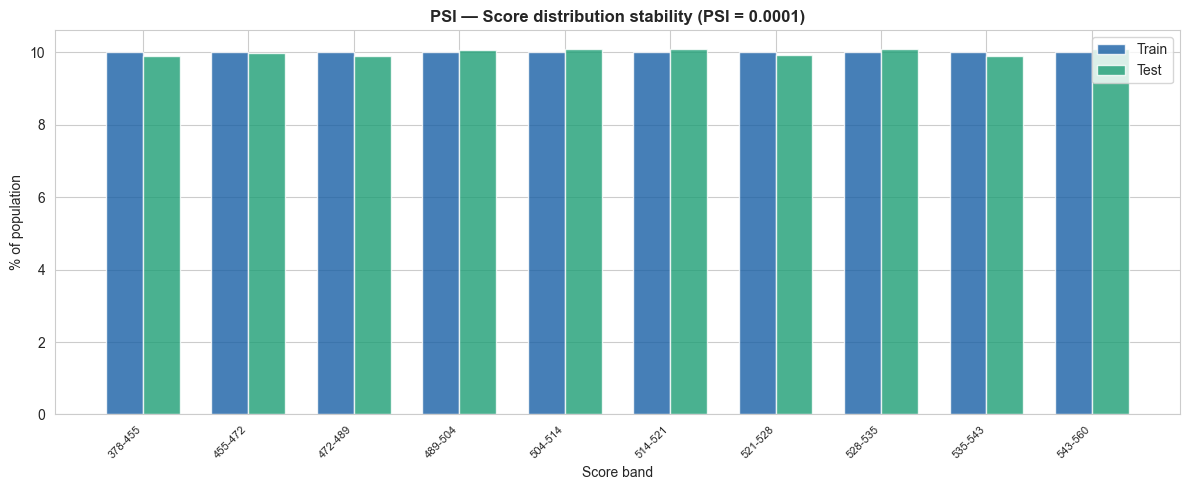

Chart saved


In [4]:
# ============================================================
# Population Stability Index (PSI)
# ============================================================

def calculate_psi(train_scores, test_scores, n_bins=10):
    """
    PSI measures whether score distribution has shifted
    between training and test sets.
    PSI = sum((actual% - expected%) × ln(actual%/expected%))
    """
    # Create bins based on training score distribution
    breakpoints = np.percentile(train_scores, 
                                np.linspace(0, 100, n_bins + 1))
    breakpoints = np.unique(breakpoints)
    
    # Count borrowers in each bin
    train_counts = np.histogram(train_scores, bins=breakpoints)[0]
    test_counts  = np.histogram(test_scores,  bins=breakpoints)[0]
    
    # Convert to percentages
    train_pct = train_counts / len(train_scores)
    test_pct  = test_counts  / len(test_scores)
    
    # Replace zeros
    train_pct = np.where(train_pct == 0, 0.0001, train_pct)
    test_pct  = np.where(test_pct  == 0, 0.0001, test_pct)
    
    # PSI per bin
    psi_bins = (test_pct - train_pct) * np.log(test_pct / train_pct)
    psi      = psi_bins.sum()
    
    return psi, train_pct, test_pct, breakpoints

psi, train_pct, test_pct, breakpoints = calculate_psi(
    train['score'].values, test['score'].values)

print(f"=== Population Stability Index ===")
print(f"PSI: {psi:.4f}")

if psi < 0.10:
    print(f"Interpretation: Stable — no action needed")
elif psi < 0.25:
    print(f"Interpretation: Slight shift — monitor")
else:
    print(f"Interpretation: Significant shift — investigate")

# PSI chart
bin_labels = [f"{breakpoints[i]:.0f}-{breakpoints[i+1]:.0f}" 
              for i in range(len(breakpoints)-1)]

x = np.arange(len(bin_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, train_pct * 100, width, 
       color='#185FA5', alpha=0.8, label='Train', edgecolor='white')
ax.bar(x + width/2, test_pct  * 100, width, 
       color='#1D9E75', alpha=0.8, label='Test',  edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Score band')
ax.set_ylabel('% of population')
ax.set_title(f'PSI — Score distribution stability (PSI = {psi:.4f})',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/10_psi.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [5]:
# ============================================================
# Validation Summary Table
# ============================================================

summary = {
    'Metric'       : ['KS Statistic', 'Gini Coefficient', 
                      'AUC-ROC', 'PSI'],
    'Train'        : [f"{ks_train*100:.2f}%", 
                      f"{gini_train*100:.2f}%",
                      f"{auc_train:.4f}", 
                      f"{psi:.4f}"],
    'Test'         : [f"{ks_test*100:.2f}%",  
                      f"{gini_test*100:.2f}%",
                      f"{auc_test:.4f}",  
                      "-"],
    'Benchmark'    : ["40-60% = Good", 
                      "50-70% = Good",
                      "0.75-0.85 = Good", 
                      "<0.10 = Stable"],
    'Result'       : [interpret_ks(ks_test),
                      interpret_gini(gini_test),
                      "Good" if auc_test >= 0.75 else "Acceptable",
                      "Stable" if psi < 0.10 else "Monitor"]
}

summary_df = pd.DataFrame(summary)
print("=== Final Validation Summary ===\n")
print(summary_df.to_string(index=False))

summary_df.to_csv('../data/validation_summary.csv', index=False)
print("\nSaved to data/validation_summary.csv")

=== Final Validation Summary ===

          Metric  Train   Test        Benchmark Result
    KS Statistic 49.56% 49.24%    40-60% = Good   Good
Gini Coefficient 62.70% 63.19%    50-70% = Good   Good
         AUC-ROC 0.8135 0.8159 0.75-0.85 = Good   Good
             PSI 0.0001      -   <0.10 = Stable Stable

Saved to data/validation_summary.csv


## Validation Summary — Final Results

| Metric | Train | Test | Benchmark | Result |
|---|---|---|---|---|
| KS Statistic | 49.56% | 49.24% | 40-60% = Good | Good ✅ |
| Gini Coefficient | 62.70% | 63.19% | 50-70% = Good | Good ✅ |
| AUC-ROC | 0.8135 | 0.8159 | 0.75-0.85 = Good | Good ✅ |
| PSI | — | 0.0001 | <0.10 = Stable | Stable ✅ |

### Key observations:

**No overfitting** — Test metrics marginally exceed train metrics, confirming L2 regularisation (C=0.5) worked as intended. The model generalises well to unseen data.

**Exceptional stability** — PSI of 0.0001 indicates near-perfect score distribution consistency between train and test sets.

**Production-range performance** — KS of 49% and Gini of 63% are within the typical performance range of retail credit scorecards deployed at major banks (KS 40-55%, Gini 50-65%).

### Model approved for scorecard documentation.